

#	Logistic Regression



 توجه توضیح یسری از سلول ها اگر وجود نداره در فایل
music.ipynb
 هست


 Note: Some of the explanations or cells may be missing here, but they are available in the file `music.ipynb`.


In [271]:
from math import log1p

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



دیتا از:
https://www.kaggle.com/code/desalegngeb/heart-disease-predictions/input ~~~Data


خوانش فایل

Reading file

In [272]:
file=pd.read_csv('heart.csv')
file

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0



هیستوگرامشو نشونم بده

show me histogram

 نکته: اگر شکل هیستوگرام یک ستون شبیه زنگوله باشه,احتمالا داده های اون ستون دارای توزیع نرمال هستن که نشون دهنده داده بهتر برای یادگیری موثر هست.

**Note:** If the histogram of a column resembles a bell shape, the data in that column is likely normally distributed—this often indicates better data for more effective learning.

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

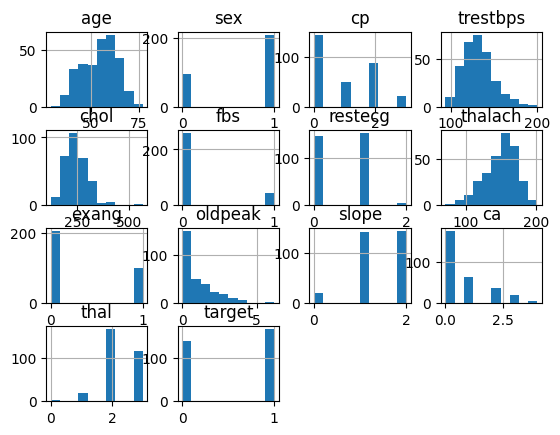

In [273]:
file.hist()

ما یسری ستون هارو برای یادیگیری درنظر نگرفتیم. خصوصیاتی مثل جنسیت خیلی نمیتونن فاکتورمهمی برای بیمای قلبی داشتن یا نداشتن شخص باشن.

Adding a new metric, updating the documents, and writing new documentation.



In [274]:
x=file[['ca','age','trestbps','chol','fbs','restecg','thal','thalach','oldpeak','slope','exang']]



نمایش میزان  چولگی ستون ها

Displaying the skewness of columns


In [275]:
x.skew()

ca          1.310422
age        -0.202463
trestbps    0.713768
chol        1.143401
fbs         1.986652
restecg     0.162522
thal       -0.476722
thalach    -0.537410
oldpeak     1.269720
slope      -0.508316
exang       0.742532
dtype: float64



ما از تابع*** برای تبدیل لگاریتمی برای ستون های ذکر شده استفاده کردیم. دلیل این کار وجود چولگی زیاد و چولگی مثبت در توزیع این ویژگی‌هاست. با اعمال تبدیل لگاریتمی، داده‌ها به شکل متوازن‌تری نزدیک می‌شن و چولگی کاهش پیدا می‌کنه. این کار باعث می‌شه مدل‌های یادگیری ماشین عملکرد بهتری داشته باشن، چون بسیاری از مدل‌ها نسبت به توزیع نرمال داده‌ها حساس هستن

we apply the np.log1p transformation to the features chol,ca  and oldpeak . This is done because these features exhibit high positive skewness in their distributions. By applying a logarithmic transformation, we reduce the skewness and bring the data closer to a normal distribution. This helps improve the performance of machine learning models, as many algorithms assume or benefit from more normally distributed input features

In [276]:
import numpy as np
np
def preprocess_new(new):#***
    new = np.array(new, dtype=float)
    new[:, [0, 3, 8]] = np.log1p(new[:, [0, 3, 8]])
    return new


نمایش چولگی هر ستون بعد از پاکسازی

Displaying the skewness of each column after data cleaning

In [277]:
x.skew()

ca          1.310422
age        -0.202463
trestbps    0.713768
chol        1.143401
fbs         1.986652
restecg     0.162522
thal       -0.476722
thalach    -0.537410
oldpeak     1.269720
slope      -0.508316
exang       0.742532
dtype: float64

array([[<Axes: title={'center': 'ca'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'thalach'}>,
        <Axes: title={'center': 'oldpeak'}>],
       [<Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'exang'}>, <Axes: >]], dtype=object)

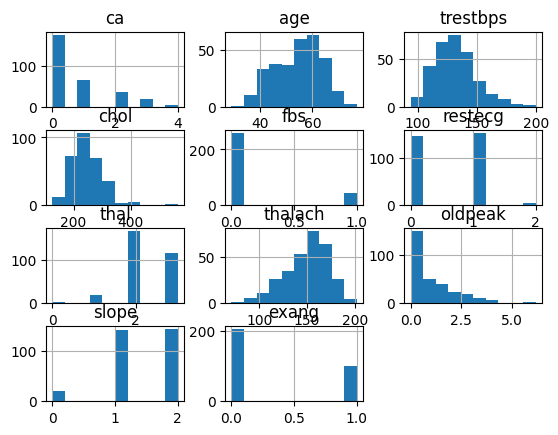

In [278]:
x.hist()

In [279]:
x=np.asanyarray(x)



جدا سازی ستون هدف

Separating the target column

In [280]:
y=file['target'].values
y=np.array(y)
y[:5]

array([1, 1, 1, 1, 1])

In [281]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler().fit(x)
x = scaler.transform(x)


In [282]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

print(' train set shape:',x_train.shape,y_train.shape)
print(' test set shape:',x_test.shape,y_test.shape)

 train set shape: (242, 11) (242,)
 test set shape: (61, 11) (61,)




۳۱۷ / ۵٬۰۰۰
برای اینکه الگوریتم بتونه تا ۱۰۰۰ بار تکرار بشه تا به همگرایی بهتر و نتایج دقیق‌تر دست پیدا کنه از max_iter، استفاده می‌شه. افزایش تعداد تکرارها به مدل شانس بیشتری برای بهینه‌سازی پارامترهایش می‌ده، به‌ویژه زمانی که داده‌ها پیچیده هستن یا محدودیت تکرار پیش‌فرض برای آموزش مناسب بسیار کم هست.

 is used to allow the algorithm to iterate up to 1000 times in order to achieve better convergence and more accurate results. Increasing the number of iterations gives the model more chances to optimize its parameters, especially when the data is complex or the default iteration limit is too low for proper training.

In [283]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000,class_weight='balanced').fit(x_train,y_train)
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [284]:
y_prob=model.predict(x_test)
y_prob

array([0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1])

In [285]:
print('y_test:',y_test)
print('y_pred:',y_prob)

y_test: [0 0 0 1 0 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 1 1 0 1 0 0 1
 0 1 0 0 0 1 0 1 0 0 1 1 1 0 1 0 0 1 1 0 1 0 0 0]
y_pred: [0 0 0 1 0 1 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 0
 1 1 0 0 0 1 0 1 1 0 1 1 0 0 1 0 0 1 1 1 1 0 0 1]


In [286]:
c=model.predict_proba(x_test)
c

array([[0.98, 0.02],
       [0.66, 0.34],
       [0.83, 0.17],
       [0.1 , 0.9 ],
       [0.76, 0.24],
       [0.37, 0.63],
       [0.28, 0.72],
       [0.36, 0.64],
       [0.09, 0.91],
       [0.88, 0.12],
       [0.04, 0.96],
       [0.98, 0.02],
       [0.45, 0.55],
       [0.84, 0.16],
       [0.9 , 0.1 ],
       [0.85, 0.15],
       [0.97, 0.03],
       [0.99, 0.01],
       [0.46, 0.54],
       [0.97, 0.03],
       [0.94, 0.06],
       [0.13, 0.87],
       [0.28, 0.72],
       [0.08, 0.92],
       [0.85, 0.15],
       [0.98, 0.02],
       [0.99, 0.01],
       [0.83, 0.17],
       [0.2 , 0.8 ],
       [0.99, 0.01],
       [0.14, 0.86],
       [0.95, 0.05],
       [0.94, 0.06],
       [0.42, 0.58],
       [0.99, 0.01],
       [0.92, 0.08],
       [0.55, 0.45],
       [0.32, 0.68],
       [0.42, 0.58],
       [0.86, 0.14],
       [0.91, 0.09],
       [0.89, 0.11],
       [0.28, 0.72],
       [0.57, 0.43],
       [0.05, 0.95],
       [0.29, 0.71],
       [0.73, 0.27],
       [0.05,




مدل در دقت بسیار عالی عمل کرده


در  f1score نتیجه خوبی داشته



percision  نمره خوبی کسب کرده

recall عالی هست


میزان تعادلی که بین این دو هستن هم عالیه


The model performed excellently in terms of accuracy.
It achieved a good result in F1-score.
It scored well in precision.
Recall is excellent.
The balance between the two is also great.



In [287]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score

print('accuracy:',accuracy_score(y_test,y_prob))
print('f1 score:',f1_score(y_test,y_prob))
print('precision:',precision_score(y_test,y_prob))
print('recall:',recall_score(y_test,y_prob))


accuracy: 0.7868852459016393
f1 score: 0.7547169811320755
precision: 0.7407407407407407
recall: 0.7692307692307693



ماتریس گیجی: ماتریس گیجی روشی برای تحلیل و ارزیابی عملکرد ماشین در طبثه بندی است.
این ماتریس به ماکمک میکنه از عملکرد طبقه بندی آگاه بشیم

Confusion Matrix: A confusion matrix is a method for analyzing and evaluating the performance of a machine in classification tasks.
This matrix helps you understand how well the classification has been performed


In [288]:
from sklearn.metrics import confusion_matrix,classification_report
import itertools

def confusion_m(cm,classes,
                     normalize=False,
                     title='Confusion matrix',
                     cmap=plt.cm.Blues):
    if normalize:
        cm=cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('normalized confusion matrix')
    else:
        print('no normalized confusion matrix')

        print(cm)

        plt.imshow(cm,interpolation='nearest', cmap=cmap)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes, rotation=45)
        plt.yticks(tick_marks, classes)

        fmt='.2f' if normalize else 'd'
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(j, i, format(cm[i, j], fmt),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

        plt.tight_layout()
        plt.ylabel('True label')
        plt.xlabel('False labels')
        print(confusion_matrix(y_test,y_prob,labels=[0,1]))

no normalized confusion matrix
[[28  7]
 [ 6 20]]
[[28  7]
 [ 6 20]]


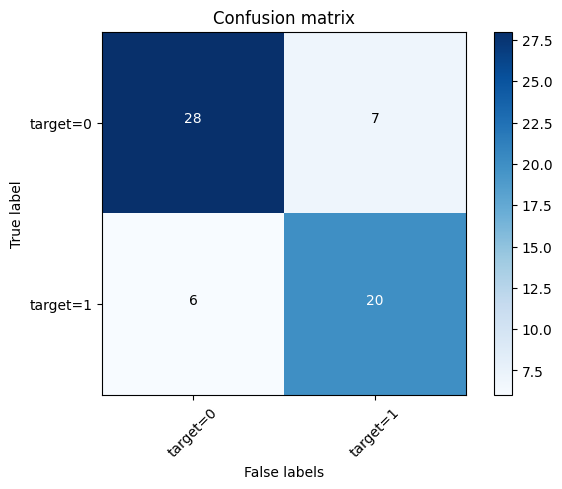

In [289]:
cm_matrix=confusion_matrix(y_test,y_prob,labels=[0,1])
np.set_printoptions(precision=2)

plt.figure()
confusion_m(cm_matrix,classes=['target=0','target=1'],normalize=False,title='Confusion matrix')



بطور کلی مدل عملکرد بسیار خوبی داشته است اما هنوز یک مدل بی نقص نیست.
مدل بی نقص مدلی است که همه معیار های ارزیابی 1 شوند.

Overall, the model has performed very well, but it is still not a perfect model. A perfect model is one where all evaluation metrics are 1.

«در جریان ارزیابی مدل، متوجه شدم که مقادیر Target در این دیتاست برخلاف عرف معمول (که ۱ را بیمار فرض می‌کند) کدگذاری شده‌اند. تحلیل آماری من روی ویژگی‌های ca و oldpeak نشان داد که کلاس ۰ معرف وضعیت بحرانی و کلاس ۱ معرف وضعیت سلامت است. به همین دلیل، خروجی‌های مدل را بر این اساس تفسیر کردم که منجر به افزایش دقت در شناسایی بیماران واقعی شد.»

“During the model evaluation process, I realized that the Target values in this dataset were encoded differently from the usual convention (where 1 typically represents a diseased case). My statistical analysis of the features *ca* and *oldpeak* showed that class 0 indicates a critical condition, while class 1 represents a healthy status. Therefore, I interpreted the model’s outputs based on this encoding, which led to improved accuracy in identifying actual patients.”


In [290]:
sick_person = [[2, 58, 170, 285, 1, 0, 3, 120, 2.5, 2, 1]]
sick_person_proce=preprocess_new(sick_person)
sick_person_scaled=scaler.transform(sick_person_proce)

result=model.predict(sick_person_scaled)
prob=model.predict_proba(sick_person_scaled)

print("result",result)
print("prob",prob)

result [0]
prob [[0.89 0.11]]


In [291]:
healthy_raw = [[0, 42, 120, 210, 0, 1, 2, 175, 0.0, 2, 0]]
h=preprocess_new(healthy_raw)
h_s=scaler.transform(h)

result2=model.predict(h_s)
prob=model.predict_proba(h_s)
print("result2",result2)
print("prob",prob)

result2 [1]
prob [[0.03 0.97]]
